In [ ]:
import pandas as pd
import os
import sys
import json
from pathlib import Path
import numpy as np

# Notebook is in notebooks/, so repo root is parent
REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT))

In [28]:
import importlib
import models.xgboost_baseline as xb

importlib.reload(xb)

<module 'models.xgboost_baseline' from '/Users/brandonng/Documents/GitHub/ClinicalDigitalTwin/src/models/xgboost_baseline.py'>

In [29]:
from models.xgboost_baseline import load_data_files

# Get repo root relative to the current notebook
repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))

# Load static preprocessing config
config_path = os.path.join(repo_root, "configs", "xgboost_baseline_params.json")
with open(config_path, "r") as f:
    config = json.load(f)

# Set input and output directories
in_dir = os.path.join(repo_root, config["paths"]["in_dir"])


ed_vitals, clinical_encounters, ecg_records = load_data_files(in_dir, config)

In [30]:
ed_vitals.head(5)
print(ed_vitals.shape)
print(ed_vitals['stay_id'].nunique())

(1225239, 9)
291592


In [9]:
clinical_encounters.head(5)

,subject_id,hadm_id,ed_stay_id,ed_intime,ed_outtime,hosp_admittime,hosp_dischtime,race,gender,anchor_age,...,label_renal_failure_dialysis,label_respiratory_failure_distress,label_stroke_tia,label_supraventricular_tachyarrhythmias,label_unspecified_cardiac,label_unstable_angina_ac_ischemia,label_valvular_endocardial_disease,label_ventricular_arrhythmias_arrest,is_cardiovascular,is_specified_cardiac
0,10000032,22595853.0,33258284.0,2180-05-06 19:17:00,2180-05-06 23:30:00,2180-05-06 22:23:00,2180-05-07 17:15:00,WHITE,F,52.0,...,0,0,0,0,0,0,0,0,0,0
1,10000032,22841357.0,38112554.0,2180-06-26 15:54:00,2180-06-26 21:31:00,2180-06-26 18:27:00,2180-06-27 18:49:00,WHITE,F,52.0,...,0,0,0,0,0,0,0,0,0,0
2,10000032,25742920.0,35968195.0,2180-08-05 20:58:00,2180-08-06 01:44:00,2180-08-05 23:44:00,2180-08-07 17:50:00,WHITE,F,52.0,...,0,0,0,0,0,0,0,0,0,0
3,10000032,29079034.0,39399961.0,2180-07-23 05:54:00,2180-07-23 14:00:00,2180-07-23 12:35:00,2180-07-25 17:55:00,WHITE,F,52.0,...,0,0,0,0,0,0,0,0,0,0
4,10000117,27988844.0,33176849.0,2183-09-18 08:41:00,2183-09-18 20:20:00,2183-09-18 18:10:00,2183-09-21 16:30:00,WHITE,F,48.0,...,0,0,0,0,0,0,1,0,1,1


In [10]:
print(ecg_records.shape)
ecg_records.head(5)

(403121, 85)


,subject_id,study_id,file_name,ecg_time,path,hadm_id,ed_stay_id,icu_stay_id,in_hosp,in_ed,...,report_junctional_rhythm,report_undetermined_rhythm,report_wpw_pattern,report_technical_error,report_lead_reversal,report_pericarditis,report_hyperkalemia,report_digitalis_effect,report_abnormal_p_waves,report_ventricular_response
0,16598616,40000035,40000035,2126-04-01 19:32:00,files/p1659/p16598616/s40000035/40000035,26101986.0,32731561.0,NaN,0,1,...,0,0,0,0,0,0,0,0,0,0
1,18370366,40000084,40000084,2179-08-30 11:58:00,files/p1837/p18370366/s40000084/40000084,NaN,37736561.0,NaN,0,1,...,0,0,0,0,0,0,0,0,0,0
2,12576058,40000115,40000115,2163-04-17 16:45:00,files/p1257/p12576058/s40000115/40000115,NaN,36567247.0,NaN,0,1,...,0,0,0,0,0,0,0,0,0,0
3,14691089,40000143,40000143,2175-07-21 01:01:00,files/p1469/p14691089/s40000143/40000143,23760732.0,38981935.0,NaN,0,1,...,0,0,0,0,0,0,0,0,0,0
4,16089780,40000152,40000152,2137-01-29 19:08:00,files/p1608/p16089780/s40000152/40000152,NaN,31326149.0,NaN,0,1,...,0,0,0,0,0,0,0,0,0,0


In [11]:
only_ed = ecg_records[ecg_records['in_ed'] == 0]
print(only_ed.shape)
only_ed.head(5)

(244837, 85)


,subject_id,study_id,file_name,ecg_time,path,hadm_id,ed_stay_id,icu_stay_id,in_hosp,in_ed,...,report_junctional_rhythm,report_undetermined_rhythm,report_wpw_pattern,report_technical_error,report_lead_reversal,report_pericarditis,report_hyperkalemia,report_digitalis_effect,report_abnormal_p_waves,report_ventricular_response
5,14431564,40000172,40000172,2140-01-23 09:01:00,files/p1443/p14431564/s40000172/40000172,29059040.0,NaN,NaN,1,0,...,0,0,0,0,0,0,0,0,0,0
7,17975155,40000210,40000210,2186-01-23 08:17:00,files/p1797/p17975155/s40000210/40000210,29943051.0,NaN,[31566724],1,0,...,0,0,0,0,0,0,0,0,0,0
8,15382919,40000235,40000235,2139-12-23 08:13:00,files/p1538/p15382919/s40000235/40000235,20851587.0,32812545.0,NaN,1,0,...,0,0,0,0,0,0,0,0,0,0
9,18332475,40000240,40000240,2178-11-25 07:47:00,files/p1833/p18332475/s40000240/40000240,21708734.0,33782622.0,[37542103],1,0,...,0,0,0,0,0,0,0,0,0,0
10,10753818,40000282,40000282,2137-03-02 21:13:00,files/p1075/p10753818/s40000282/40000282,22361022.0,NaN,NaN,1,0,...,0,0,0,0,0,0,0,0,0,0


In [12]:
from models.xgboost_baseline import filter_ed_encounters

ed_encounters = filter_ed_encounters(clinical_encounters)
ed_encounters.shape


(265702, 45)

In [14]:
ed_encounters.columns

Index(['subject_id', 'hadm_id', 'ed_stay_id', 'ed_intime', 'ed_outtime',
       'hosp_admittime', 'hosp_dischtime', 'race', 'gender', 'anchor_age',
       'death_time', 'icu_stay_id', 'icu_intime', 'icu_outtime', 'icu_count',
       'diagnosis', 'icd_codes', 'labels', 'label_afib_aflutter',
       'label_ami_nstemi', 'label_ami_stemi', 'label_anemia_hematologic',
       'label_aortic_peripheral_vascular',
       'label_brady_heart_block_conduction',
       'label_cardiomyopathy_myocarditis', 'label_chronic_ischemic_disease',
       'label_gi_hepatic_complications', 'label_heart_failure_acute',
       'label_heart_failure_chronic', 'label_hypertension_crisis',
       'label_infectious_pneumonia_sepsis', 'label_metabolic_diabetes',
       'label_obstructive_lung_disease', 'label_pe_dvt_venous_thromboembolism',
       'label_pericardial_disease_tamponade', 'label_renal_failure_dialysis',
       'label_respiratory_failure_distress', 'label_stroke_tia',
       'label_supraventricular_tachya

In [13]:
from models.xgboost_baseline import filter_ed_ecg_records

ed_ecg_records = filter_ed_ecg_records(ecg_records)
ed_ecg_records.shape



(158284, 61)

In [15]:
ed_vitals.columns

Index(['subject_id', 'stay_id', 'charttime', 'temperature', 'heartrate',
       'resprate', 'o2sat', 'sbp', 'dbp'],
      dtype='object')

In [16]:
from models.xgboost_baseline import extract_earliest_ecg_per_stay

earliest_ecgs = extract_earliest_ecg_per_stay(ed_ecg_records)

earliest_ecgs.head(5)

,subject_id,ed_stay_id,study_id,file_name,ecg_time,path,hadm_id,icu_stay_id,in_hosp,in_ed,...,report_ectopic_atrial_rhythm,report_junctional_rhythm,report_undetermined_rhythm,report_wpw_pattern,report_technical_error,report_lead_reversal,report_hyperkalemia,qrs_duration,pr_interval,qt_proxy
0,10000032,39399961.0,40689238,40689238,2180-07-23 08:44:00,files/p1000/p10000032/s40689238/40689238,29079034.0,[39553978],0,1,...,0,0,0,0,0,0,0,88,130,348
1,10000117,33176849.0,48446569,48446569,2183-09-18 13:52:00,files/p1000/p10000117/s48446569/48446569,27988844.0,None,0,1,...,0,0,0,0,0,0,0,86,136,364
2,10000285,37909301.0,42709053,42709053,2159-11-26 14:29:00,files/p1000/p10000285/s42709053/42709053,NaN,None,0,1,...,0,0,0,0,0,0,0,93,134,353
3,10000635,31767754.0,44095784,44095784,2138-09-29 11:09:00,files/p1000/p10000635/s44095784/44095784,NaN,None,0,1,...,0,0,0,0,0,0,0,102,144,530
4,10000898,30017875.0,43492795,43492795,2188-03-13 14:32:00,files/p1000/p10000898/s43492795/43492795,NaN,None,0,1,...,0,0,0,0,0,0,0,84,186,386


In [17]:
from models.xgboost_baseline import preprocess_vitals

preprocessed_ed_vitals = preprocess_vitals(ed_vitals)
print(preprocessed_ed_vitals.shape)
print(preprocessed_ed_vitals['stay_id'].nunique())
print(preprocessed_ed_vitals.columns)
preprocessed_ed_vitals.head(5)

(1225239, 9)
291592
Index(['subject_id', 'stay_id', 'charttime', 'temperature', 'heartrate',
       'resprate', 'o2sat', 'sbp', 'dbp'],
      dtype='object')


,subject_id,stay_id,charttime,temperature,heartrate,resprate,o2sat,sbp,dbp
0,17195991,38649090,2110-01-11 21:45:00,NaN,141.0,24.0,94.0,NaN,NaN
1,17195991,38649090,2110-01-11 21:50:00,NaN,123.0,24.0,91.0,151.0,120.0
2,17195991,38649090,2110-01-11 22:00:00,NaN,133.0,23.0,99.0,180.0,86.0
3,17195991,38649090,2110-01-11 22:07:00,NaN,164.0,24.0,99.0,198.0,116.0
4,17195991,38649090,2110-01-11 22:23:00,NaN,130.0,16.0,100.0,235.0,126.0


In [18]:
earliest_ecgs.shape

(127410, 64)

In [19]:
print(preprocessed_ed_vitals.columns)

print(ed_encounters.columns[:18])

print(earliest_ecgs.columns[:26])

Index(['subject_id', 'stay_id', 'charttime', 'temperature', 'heartrate',
       'resprate', 'o2sat', 'sbp', 'dbp'],
      dtype='object')
Index(['subject_id', 'hadm_id', 'ed_stay_id', 'ed_intime', 'ed_outtime',
       'hosp_admittime', 'hosp_dischtime', 'race', 'gender', 'anchor_age',
       'death_time', 'icu_stay_id', 'icu_intime', 'icu_outtime', 'icu_count',
       'diagnosis', 'icd_codes', 'labels'],
      dtype='object')
Index(['subject_id', 'ed_stay_id', 'study_id', 'file_name', 'ecg_time', 'path',
       'hadm_id', 'icu_stay_id', 'in_hosp', 'in_ed', 'in_icu',
       'icu_within_12hrs', 'icu_within_24hrs', 'cart_id', 'bandwidth',
       'filtering', 'rr_interval', 'p_onset', 'p_end', 'qrs_onset', 'qrs_end',
       't_end', 'p_axis', 'qrs_axis', 't_axis', 'full_report'],
      dtype='object')


In [20]:
from models.xgboost_baseline import aggregate_vitals_to_ecg_time

ecg_aggregate_vitals = aggregate_vitals_to_ecg_time(preprocessed_ed_vitals, earliest_ecgs, agg_window_hours=4.0)
print(ecg_aggregate_vitals.shape)
ecg_aggregate_vitals.head(5)

(127410, 95)


,subject_id,ed_stay_id,study_id,file_name,ecg_time,path,hadm_id,icu_stay_id,in_hosp,in_ed,...,dbp_std,dbp_min,dbp_max,temperature_closest,heartrate_closest,resprate_closest,o2sat_closest,sbp_closest,dbp_closest,vitals_time_before_ecg
0,10000032,39399961.0,40689238,40689238,2180-07-23 08:44:00,files/p1000/p10000032/s40689238/40689238,29079034.0,[39553978],0,1,...,1.154701,55.0,57.0,NaN,78.0,18.0,94.0,82.0,55.0,0 days 00:14:00
1,10000117,33176849.0,48446569,48446569,2183-09-18 13:52:00,files/p1000/p10000117/s48446569/48446569,27988844.0,None,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
2,10000285,37909301.0,42709053,42709053,2159-11-26 14:29:00,files/p1000/p10000285/s42709053/42709053,NaN,None,0,1,...,NaN,99.0,99.0,98.0,80.0,19.0,100.0,141.0,99.0,0 days 00:07:00
3,10000635,31767754.0,44095784,44095784,2138-09-29 11:09:00,files/p1000/p10000635/s44095784/44095784,NaN,None,0,1,...,NaN,67.0,67.0,97.1,56.0,16.0,100.0,139.0,67.0,0 days 00:14:00
4,10000898,30017875.0,43492795,43492795,2188-03-13 14:32:00,files/p1000/p10000898/s43492795/43492795,NaN,None,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT


In [21]:
ecg_aggregate_vitals.columns

Index(['subject_id', 'ed_stay_id', 'study_id', 'file_name', 'ecg_time', 'path',
       'hadm_id', 'icu_stay_id', 'in_hosp', 'in_ed', 'in_icu',
       'icu_within_12hrs', 'icu_within_24hrs', 'cart_id', 'bandwidth',
       'filtering', 'rr_interval', 'p_onset', 'p_end', 'qrs_onset', 'qrs_end',
       't_end', 'p_axis', 'qrs_axis', 't_axis', 'full_report',
       'report_sinus_rhythm', 'report_sinus_bradycardia',
       'report_sinus_tachycardia', 'report_atrial_fibrillation',
       'report_atrial_flutter', 'report_supraventricular_tachycardia',
       'report_ventricular_tachycardia', 'report_right_bundle_branch_block',
       'report_left_bundle_branch_block',
       'report_left_anterior_fascicular_block',
       'report_left_posterior_fascicular_block', 'report_aberrant_conduction',
       'report_left_ventricular_hypertrophy',
       'report_right_ventricular_hypertrophy', 'report_biatrial_enlargement',
       'report_left_atrial_enlargement', 'report_right_atrial_enlargement',
    

In [22]:
ed_encounters.columns

Index(['subject_id', 'hadm_id', 'ed_stay_id', 'ed_intime', 'ed_outtime',
       'hosp_admittime', 'hosp_dischtime', 'race', 'gender', 'anchor_age',
       'death_time', 'icu_stay_id', 'icu_intime', 'icu_outtime', 'icu_count',
       'diagnosis', 'icd_codes', 'labels', 'label_afib_aflutter',
       'label_ami_nstemi', 'label_ami_stemi', 'label_anemia_hematologic',
       'label_aortic_peripheral_vascular',
       'label_brady_heart_block_conduction',
       'label_cardiomyopathy_myocarditis', 'label_chronic_ischemic_disease',
       'label_gi_hepatic_complications', 'label_heart_failure_acute',
       'label_heart_failure_chronic', 'label_hypertension_crisis',
       'label_infectious_pneumonia_sepsis', 'label_metabolic_diabetes',
       'label_obstructive_lung_disease', 'label_pe_dvt_venous_thromboembolism',
       'label_pericardial_disease_tamponade', 'label_renal_failure_dialysis',
       'label_respiratory_failure_distress', 'label_stroke_tia',
       'label_supraventricular_tachya

In [23]:
from models.xgboost_baseline import create_model_df

model_df = create_model_df(ed_encounters, ecg_aggregate_vitals)
print(model_df.shape)
model_df.head(5)

(127410, 138)


,subject_id,ed_stay_id,study_id,file_name,ecg_time,path,hadm_id_x,icu_stay_id_x,in_hosp,in_ed,...,label_renal_failure_dialysis,label_respiratory_failure_distress,label_stroke_tia,label_supraventricular_tachyarrhythmias,label_unspecified_cardiac,label_unstable_angina_ac_ischemia,label_valvular_endocardial_disease,label_ventricular_arrhythmias_arrest,is_cardiovascular,is_specified_cardiac
0,10000032,39399961,40689238,40689238,2180-07-23 08:44:00,files/p1000/p10000032/s40689238/40689238,29079034.0,[39553978],0,1,...,0,0,0,0,0,0,0,0,0,0
1,10000117,33176849,48446569,48446569,2183-09-18 13:52:00,files/p1000/p10000117/s48446569/48446569,27988844.0,None,0,1,...,0,0,0,0,0,0,1,0,1,1
2,10000285,37909301,42709053,42709053,2159-11-26 14:29:00,files/p1000/p10000285/s42709053/42709053,NaN,None,0,1,...,0,0,0,0,0,0,0,0,0,0
3,10000635,31767754,44095784,44095784,2138-09-29 11:09:00,files/p1000/p10000635/s44095784/44095784,NaN,None,0,1,...,0,0,0,0,0,0,0,0,1,1
4,10000898,30017875,43492795,43492795,2188-03-13 14:32:00,files/p1000/p10000898/s43492795/43492795,NaN,None,0,1,...,0,0,0,0,0,0,0,0,0,0


In [24]:
# ECG FEATURES
# 'rr_interval', 'p_onset', 'p_end', 'qrs_onset', 'qrs_end',
#        't_end', 'p_axis', 'qrs_axis', 't_axis'

# VITAL SIGN AGGREGATES
# 'temperature_mean', 'temperature_std', 'temperature_min',
#        'temperature_max', 'heartrate_mean', 'heartrate_std', 'heartrate_min',
#        'heartrate_max', 'resprate_mean', 'resprate_std', 'resprate_min',
#        'resprate_max', 'o2sat_mean', 'o2sat_std', 'o2sat_min', 'o2sat_max',
#        'sbp_mean', 'sbp_std', 'sbp_min', 'sbp_max', 'dbp_mean', 'dbp_std',
#        'dbp_min', 'dbp_max', 'temperature_closest', 'heartrate_closest',
#        'resprate_closest', 'o2sat_closest', 'sbp_closest', 'dbp_closest',

# MACHINE MEASUREMENTS
# 'sinus_rhythm',
#        'sinus_bradycardia', 'sinus_tachycardia', 'atrial_fibrillation',
#        'atrial_flutter', 'supraventricular_tachycardia',
#        'ventricular_tachycardia', 'right_bundle_branch_block',
#        'left_bundle_branch_block', 'left_anterior_fascicular_block',
#        'left_posterior_fascicular_block', 'aberrant_conduction',
#        'left_ventricular_hypertrophy', 'right_ventricular_hypertrophy',
#        'biatrial_enlargement', 'left_atrial_enlargement',
#        'right_atrial_enlargement', 'axis_deviation', 'prolonged_qt', 'pacs',
#        'ventricular_bigeminy', 'ventricular_trigeminy',
#        'supraventricular_bigeminy', 'normal_ecg', 'borderline_ecg',
#        'abnormal_ecg', 'ventricular_paced_rhythm', 'sinus_arrhythmia',
#        'ectopic_atrial_rhythm', 'junctional_rhythm', 'undetermined_rhythm',
#        'wpw_pattern', 'technical_error', 'lead_reversal', 'hyperkalemia',

# DEMOGRAPHICS One hot encoded needed 
# 'race', 'gender'

# 'anchor_age'

# Labels y outcomes

In [25]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    roc_auc_score, 
    average_precision_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

from models.xgboost_baseline import prepare_model_features

X, y, y_features, output_prefix = prepare_model_features(model_df, ed_ecg_records)

In [26]:
# Check target distributions
print(f"\n{'='*70}")
print("Target Label Distributions:")
print(f"{'='*70}")
count = 0
for col in y_features:
    n_pos = y[col].sum()
    pos_rate = y[col].mean()
    if n_pos < 1000:
        count += 1
        print(f"{col}: {n_pos} cases ({pos_rate:.4%})")
print(count)


Target Label Distributions:
label_ami_stemi: 248 cases (0.1946%)
label_pericardial_disease_tamponade: 571 cases (0.4482%)
label_supraventricular_tachyarrhythmias: 896 cases (0.7032%)
label_unstable_angina_ac_ischemia: 525 cases (0.4121%)
label_ventricular_arrhythmias_arrest: 848 cases (0.6656%)
5


Training set: 60305 samples
Test set: 15233 samples
Number of targets: 66

Top 10 labels:
                                  label  train_count  test_count
0                    label_hypertension        22911        5642
1               label_diabetes_mellitus        11210        2659
2                          label_anemia         8612        2080
3         label_electrolyte_disturbance         7704        1923
4         label_coronary_artery_disease         7297        1758
5     label_atrial_fibrillation_flutter         6650        1693
6          label_chronic_kidney_disease         6474        1543
7             label_acute_kidney_injury         5863        1385
8     label_gi_bleed_or_hepatic_failure         3221         772
9  label_acute_on_chronic_heart_failure         2565         654


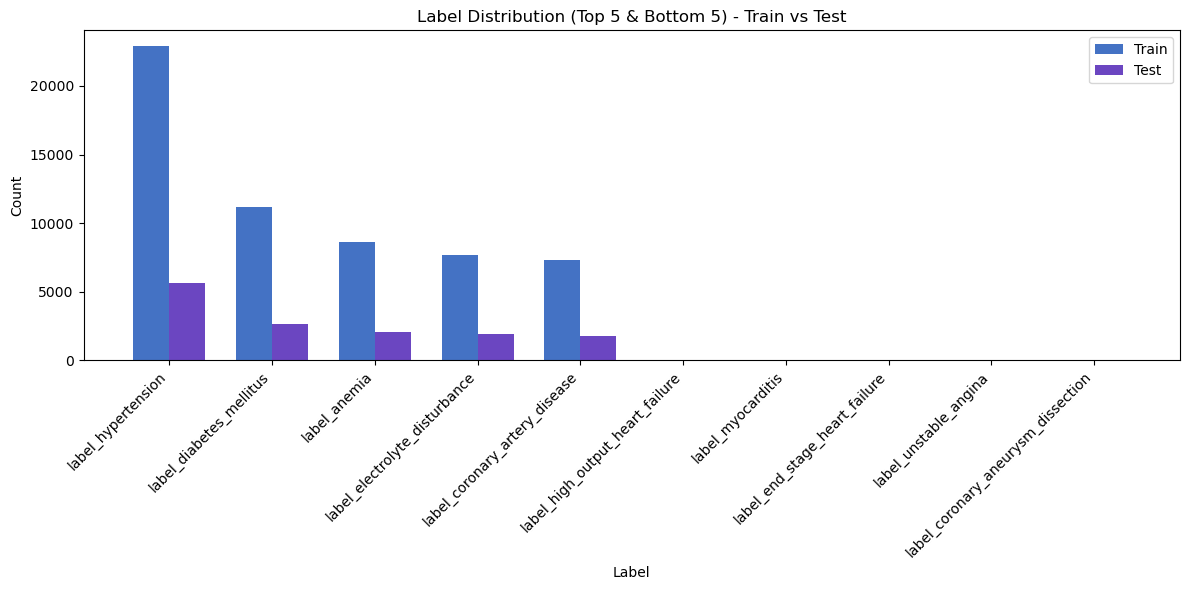

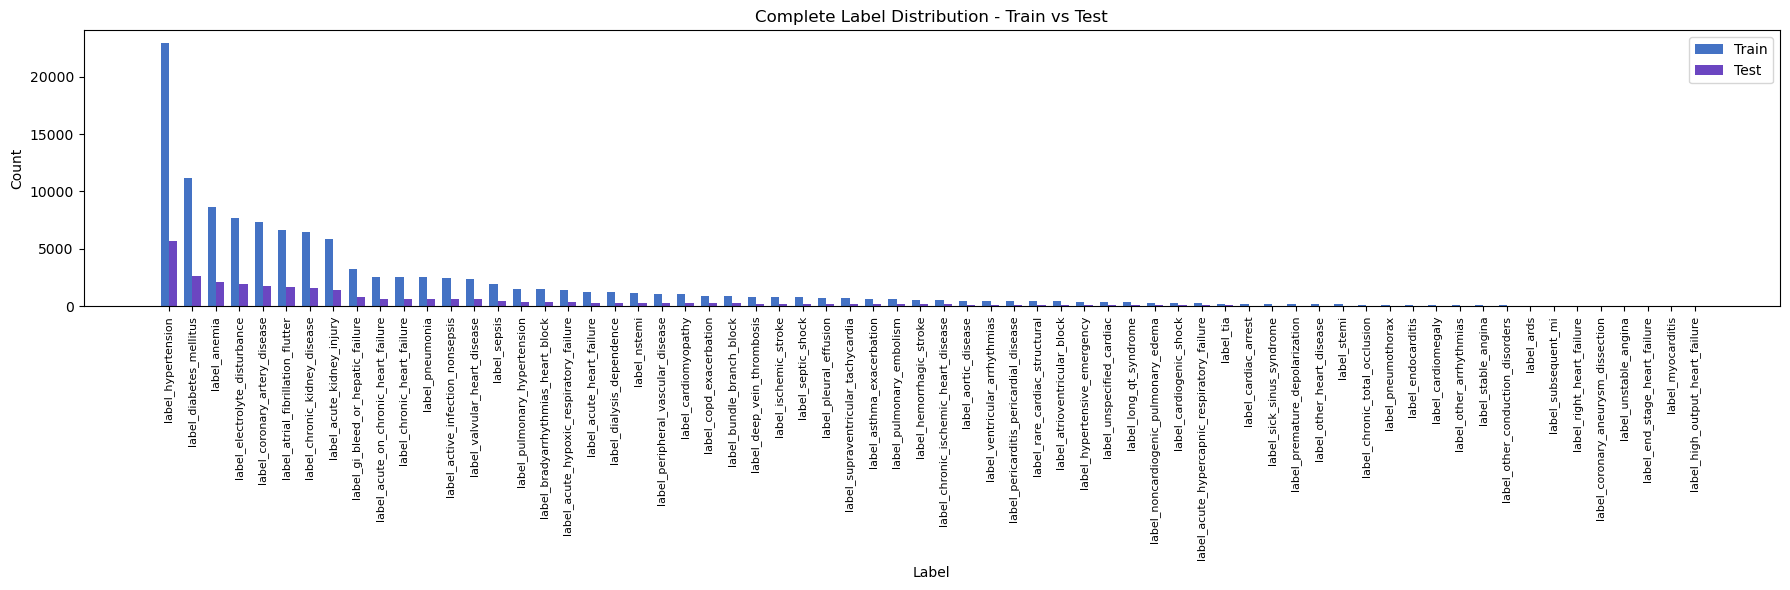


Train/Test split verification (first 5 labels):
label_hypertension: Train=80.2%, Test=19.8%
label_diabetes_mellitus: Train=80.8%, Test=19.2%
label_anemia: Train=80.5%, Test=19.5%
label_electrolyte_disturbance: Train=80.0%, Test=20.0%
label_coronary_artery_disease: Train=80.6%, Test=19.4%


In [ ]:
from models.xgboost_baseline import create_train_test_set

X_train, X_test, y_train, y_test = create_train_test_set(model_df, X, y)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Number of targets: {y_train.shape[1]}")

# Calculate label counts for train and test
train_counts = y_train.sum().sort_values(ascending=False)
test_counts = y_test.sum().sort_values(ascending=False)

# Create DataFrame for plotting
label_df = pd.DataFrame({
    'label': train_counts.index,
    'train_count': train_counts.values,
    'test_count': test_counts.values
})

# Display top 10 labels
print("\nTop 10 labels:")
print(label_df.head(10))

# Get top 5 and bottom 5 labels by total count
label_df['total_count'] = label_df['train_count'] + label_df['test_count']
top_bottom_df = pd.concat([
    label_df.nlargest(5, 'total_count'),
    label_df.nsmallest(5, 'total_count')
])

# Plot top 5 and bottom 5 (train vs test)
plt.figure(figsize=(12, 6))
x = np.arange(len(top_bottom_df))
width = 0.35

plt.bar(x - width/2, top_bottom_df['train_count'], width, 
        label='Train', color='#4472C4')
plt.bar(x + width/2, top_bottom_df['test_count'], width, 
        label='Test', color='#6B46C1')

plt.xticks(x, top_bottom_df['label'], rotation=45, ha='right')
plt.title("Label Distribution (Top 5 & Bottom 5) - Train vs Test")
plt.ylabel("Count")
plt.xlabel("Label")
plt.legend()
plt.tight_layout()
plt.show()

# Plot all labels (train vs test)
plt.figure(figsize=(18, 6))
x = np.arange(len(label_df))
width = 0.35

plt.bar(x - width/2, label_df['train_count'], width, 
        label='Train', color='#4472C4')
plt.bar(x + width/2, label_df['test_count'], width, 
        label='Test', color='#6B46C1')

plt.xticks(x, label_df['label'], rotation=90, fontsize=8)
plt.title("Complete Label Distribution - Train vs Test")
plt.ylabel("Count")
plt.xlabel("Label")
plt.legend()
plt.tight_layout()
plt.show()

# Verify split ratios
print("\nTrain/Test split verification (first 5 labels):")
for label in label_df['label'][:5]:
    train_pct = label_df[label_df['label'] == label]['train_count'].values[0] / label_df[label_df['label'] == label]['total_count'].values[0] * 100
    test_pct = label_df[label_df['label'] == label]['test_count'].values[0] / label_df[label_df['label'] == label]['total_count'].values[0] * 100
    print(f"{label}: Train={train_pct:.1f}%, Test={test_pct:.1f}%")

In [ ]:
from sklearn.multioutput import MultiOutputClassifier

# Train MultiOutputClassifier for all diagnoses
print("Training MultiOutputClassifier for diagnoses...")
print("This will train separate XGBoost models (one per label)")
print(f"{'='*70}\n")

multi_xgb = MultiOutputClassifier(
    XGBClassifier(
        max_depth=6,
        learning_rate=0.1,
        n_estimators=100,
        tree_method='hist',
        random_state=42,
        n_jobs=1
    ),
    n_jobs=-1
)

# Fit the model
multi_xgb.fit(X_train, y_train)

print("\n✓ Training complete!")
print(f"Trained {len(multi_xgb.estimators_)} separate XGBoost models")

Training MultiOutputClassifier for diagnoses...
This will train separate XGBoost models (one per label)


✓ Training complete!
Trained 66 separate XGBoost models


In [ ]:
print("Columns in y:")
print(y.columns.tolist())

Columns in y:
['label_active_infection_nonsepsis', 'label_acute_heart_failure', 'label_acute_hypercapnic_respiratory_failure', 'label_acute_hypoxic_respiratory_failure', 'label_acute_kidney_injury', 'label_acute_on_chronic_heart_failure', 'label_anemia', 'label_aortic_disease', 'label_ards', 'label_asthma_exacerbation', 'label_atrial_fibrillation_flutter', 'label_atrioventricular_block', 'label_bradyarrhythmias_heart_block', 'label_bundle_branch_block', 'label_cardiac_arrest', 'label_cardiogenic_shock', 'label_cardiomegaly', 'label_cardiomyopathy', 'label_chronic_heart_failure', 'label_chronic_ischemic_heart_disease', 'label_chronic_kidney_disease', 'label_chronic_total_occlusion', 'label_copd_exacerbation', 'label_coronary_aneurysm_dissection', 'label_coronary_artery_disease', 'label_deep_vein_thrombosis', 'label_diabetes_mellitus', 'label_dialysis_dependence', 'label_electrolyte_disturbance', 'label_end_stage_heart_failure', 'label_endocarditis', 'label_gi_bleed_or_hepatic_failure', 

In [ ]:
# Evaluate performance for each of the labels
print(f"\n{'='*70}")
print(f"PERFORMANCE FOR ALL {len(y.columns)} DIAGNOSES")  # ← Changed
print(f"{'='*70}\n")

results = []

for i, target in enumerate(y.columns):  # ← Changed from machine_report_cols
    # Get predictions for this specific label
    y_pred_proba = multi_xgb.estimators_[i].predict_proba(X_test)[:, 1]
    
    # Calculate metrics (only if both classes present in test set)
    n_pos_test = y_test[target].sum()
    n_test = len(y_test)
    
    if y_test[target].nunique() > 1:  # Both classes present
        auc = roc_auc_score(y_test[target], y_pred_proba)
        ap = average_precision_score(y_test[target], y_pred_proba)
    else:
        auc = np.nan
        ap = np.nan
    
    results.append({
        'target': target,
        'n_test_pos': int(n_pos_test),
        'pos_rate': y_test[target].mean(),
        'roc_auc': auc,
        'pr_auc': ap
    })
    
    # Print individual results
    print(f"{target}:")
    print(f"  Test positive: {int(n_pos_test)}/{n_test} ({y_test[target].mean():.4%})")
    if not np.isnan(auc):
        print(f"  ROC-AUC: {auc:.4f}")
        print(f"  PR-AUC:  {ap:.4f}")
    else:
        print(f"  Status: Single class in test set (cannot compute AUC)")
    print()

# Convert to DataFrame for analysis
results_df = pd.DataFrame(results)



PERFORMANCE FOR ALL 66 DIAGNOSES

label_active_infection_nonsepsis:
  Test positive: 588/15233 (3.8600%)
  ROC-AUC: 0.8357
  PR-AUC:  0.1265

label_acute_heart_failure:
  Test positive: 261/15233 (1.7134%)
  ROC-AUC: 0.8156
  PR-AUC:  0.0632

label_acute_hypercapnic_respiratory_failure:
  Test positive: 59/15233 (0.3873%)
  ROC-AUC: 0.9276
  PR-AUC:  0.0533

label_acute_hypoxic_respiratory_failure:
  Test positive: 346/15233 (2.2714%)
  ROC-AUC: 0.9027
  PR-AUC:  0.1909

label_acute_kidney_injury:
  Test positive: 1385/15233 (9.0921%)
  ROC-AUC: 0.8594
  PR-AUC:  0.3306

label_acute_on_chronic_heart_failure:
  Test positive: 654/15233 (4.2933%)
  ROC-AUC: 0.9228
  PR-AUC:  0.3287

label_anemia:
  Test positive: 2080/15233 (13.6546%)
  ROC-AUC: 0.8572
  PR-AUC:  0.4397

label_aortic_disease:
  Test positive: 148/15233 (0.9716%)
  ROC-AUC: 0.8199
  PR-AUC:  0.0376

label_ards:
  Test positive: 13/15233 (0.0853%)
  ROC-AUC: 0.8562
  PR-AUC:  0.0129

label_asthma_exacerbation:
  Test posi

In [ ]:
# Summary statistics
print(f"\n{'='*70}")
print("SUMMARY STATISTICS")
print(f"{'='*70}")

valid_results = results_df[results_df['roc_auc'].notna()]

print(f"\nLabels with valid metrics: {len(valid_results)}/{len(results_df)}")
print(f"Mean ROC-AUC: {valid_results['roc_auc'].mean():.4f}")
print(f"Median ROC-AUC: {valid_results['roc_auc'].median():.4f}")
print(f"Mean PR-AUC: {valid_results['pr_auc'].mean():.4f}")
print(f"Median PR-AUC: {valid_results['pr_auc'].median():.4f}")

print(f"\nTop 10 Best Performing Labels (by ROC-AUC):")
print(valid_results.nlargest(10, 'roc_auc')[['target', 'n_test_pos', 'roc_auc', 'pr_auc']].to_string(index=False))

print(f"\nBottom 10 Worst Performing Labels (by ROC-AUC):")
print(valid_results.nsmallest(10, 'roc_auc')[['target', 'n_test_pos', 'roc_auc', 'pr_auc']].to_string(index=False))


SUMMARY STATISTICS

Labels with valid metrics: 65/66
Mean ROC-AUC: 0.8352
Median ROC-AUC: 0.8464
Mean PR-AUC: 0.1349
Median PR-AUC: 0.0670

Top 10 Best Performing Labels (by ROC-AUC):
                                     target  n_test_pos  roc_auc   pr_auc
              label_end_stage_heart_failure           5 0.976609 0.013093
               label_atrioventricular_block         127 0.933996 0.247945
                  label_bundle_branch_block         213 0.933642 0.293099
label_acute_hypercapnic_respiratory_failure          59 0.927599 0.053275
                    label_cardiogenic_shock          57 0.926400 0.060106
       label_acute_on_chronic_heart_failure         654 0.922761 0.328652
         label_bradyarrhythmias_heart_block         322 0.914525 0.268281
                         label_septic_shock         192 0.912755 0.197462
       label_chronic_ischemic_heart_disease         144 0.911435 0.088129
          label_atrial_fibrillation_flutter        1693 0.907771 0.652800



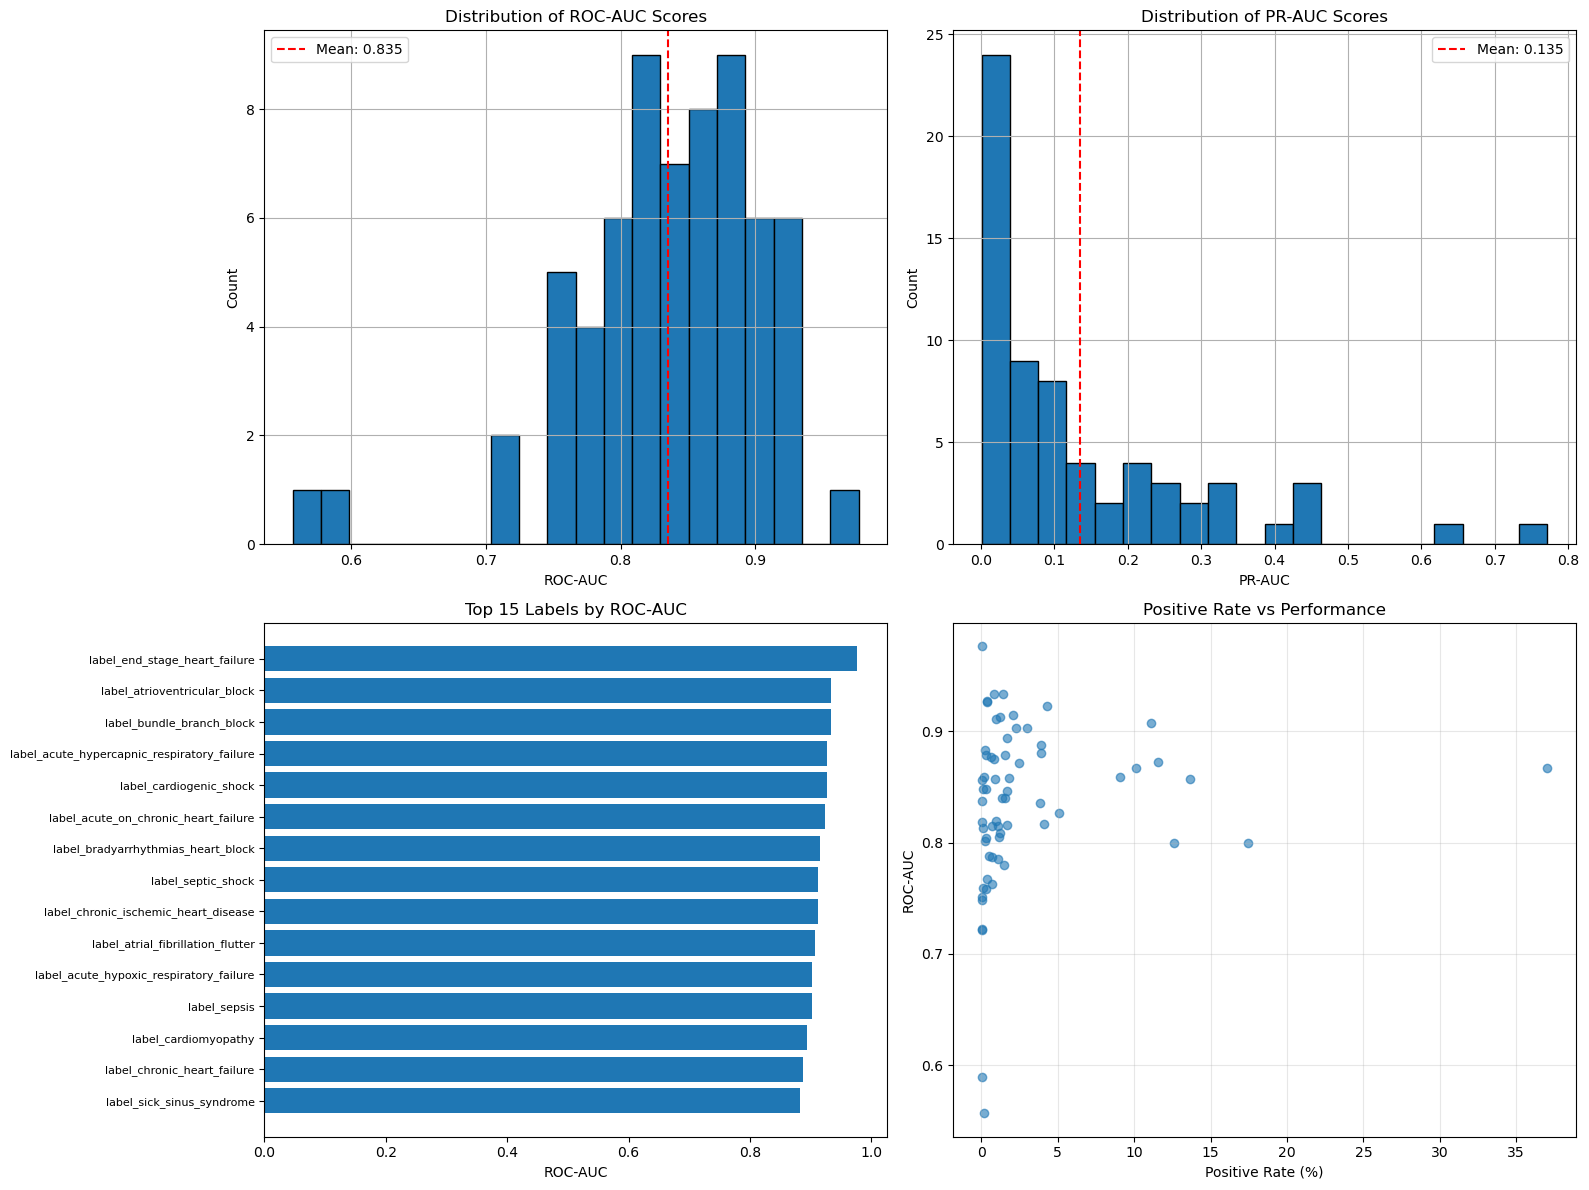

In [ ]:
# Visualize performance across all labels
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. ROC-AUC distribution
valid_results['roc_auc'].hist(bins=20, ax=axes[0, 0], edgecolor='black')
axes[0, 0].set_xlabel('ROC-AUC')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('Distribution of ROC-AUC Scores')
axes[0, 0].axvline(valid_results['roc_auc'].mean(), color='red', linestyle='--', label=f"Mean: {valid_results['roc_auc'].mean():.3f}")
axes[0, 0].legend()

# 2. PR-AUC distribution
valid_results['pr_auc'].hist(bins=20, ax=axes[0, 1], edgecolor='black')
axes[0, 1].set_xlabel('PR-AUC')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Distribution of PR-AUC Scores')
axes[0, 1].axvline(valid_results['pr_auc'].mean(), color='red', linestyle='--', label=f"Mean: {valid_results['pr_auc'].mean():.3f}")
axes[0, 1].legend()

# 3. Top 15 labels by ROC-AUC
top_15 = valid_results.nlargest(15, 'roc_auc')
axes[1, 0].barh(range(len(top_15)), top_15['roc_auc'])
axes[1, 0].set_yticks(range(len(top_15)))
axes[1, 0].set_yticklabels(top_15['target'], fontsize=8)
axes[1, 0].set_xlabel('ROC-AUC')
axes[1, 0].set_title('Top 15 Labels by ROC-AUC')
axes[1, 0].invert_yaxis()

# 4. Positive rate vs ROC-AUC
axes[1, 1].scatter(valid_results['pos_rate']*100, valid_results['roc_auc'], alpha=0.6)
axes[1, 1].set_xlabel('Positive Rate (%)')
axes[1, 1].set_ylabel('ROC-AUC')
axes[1, 1].set_title('Positive Rate vs Performance')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Visualizing: ['label_end_stage_heart_failure', 'label_nstemi', 'label_other_arrhythmias']


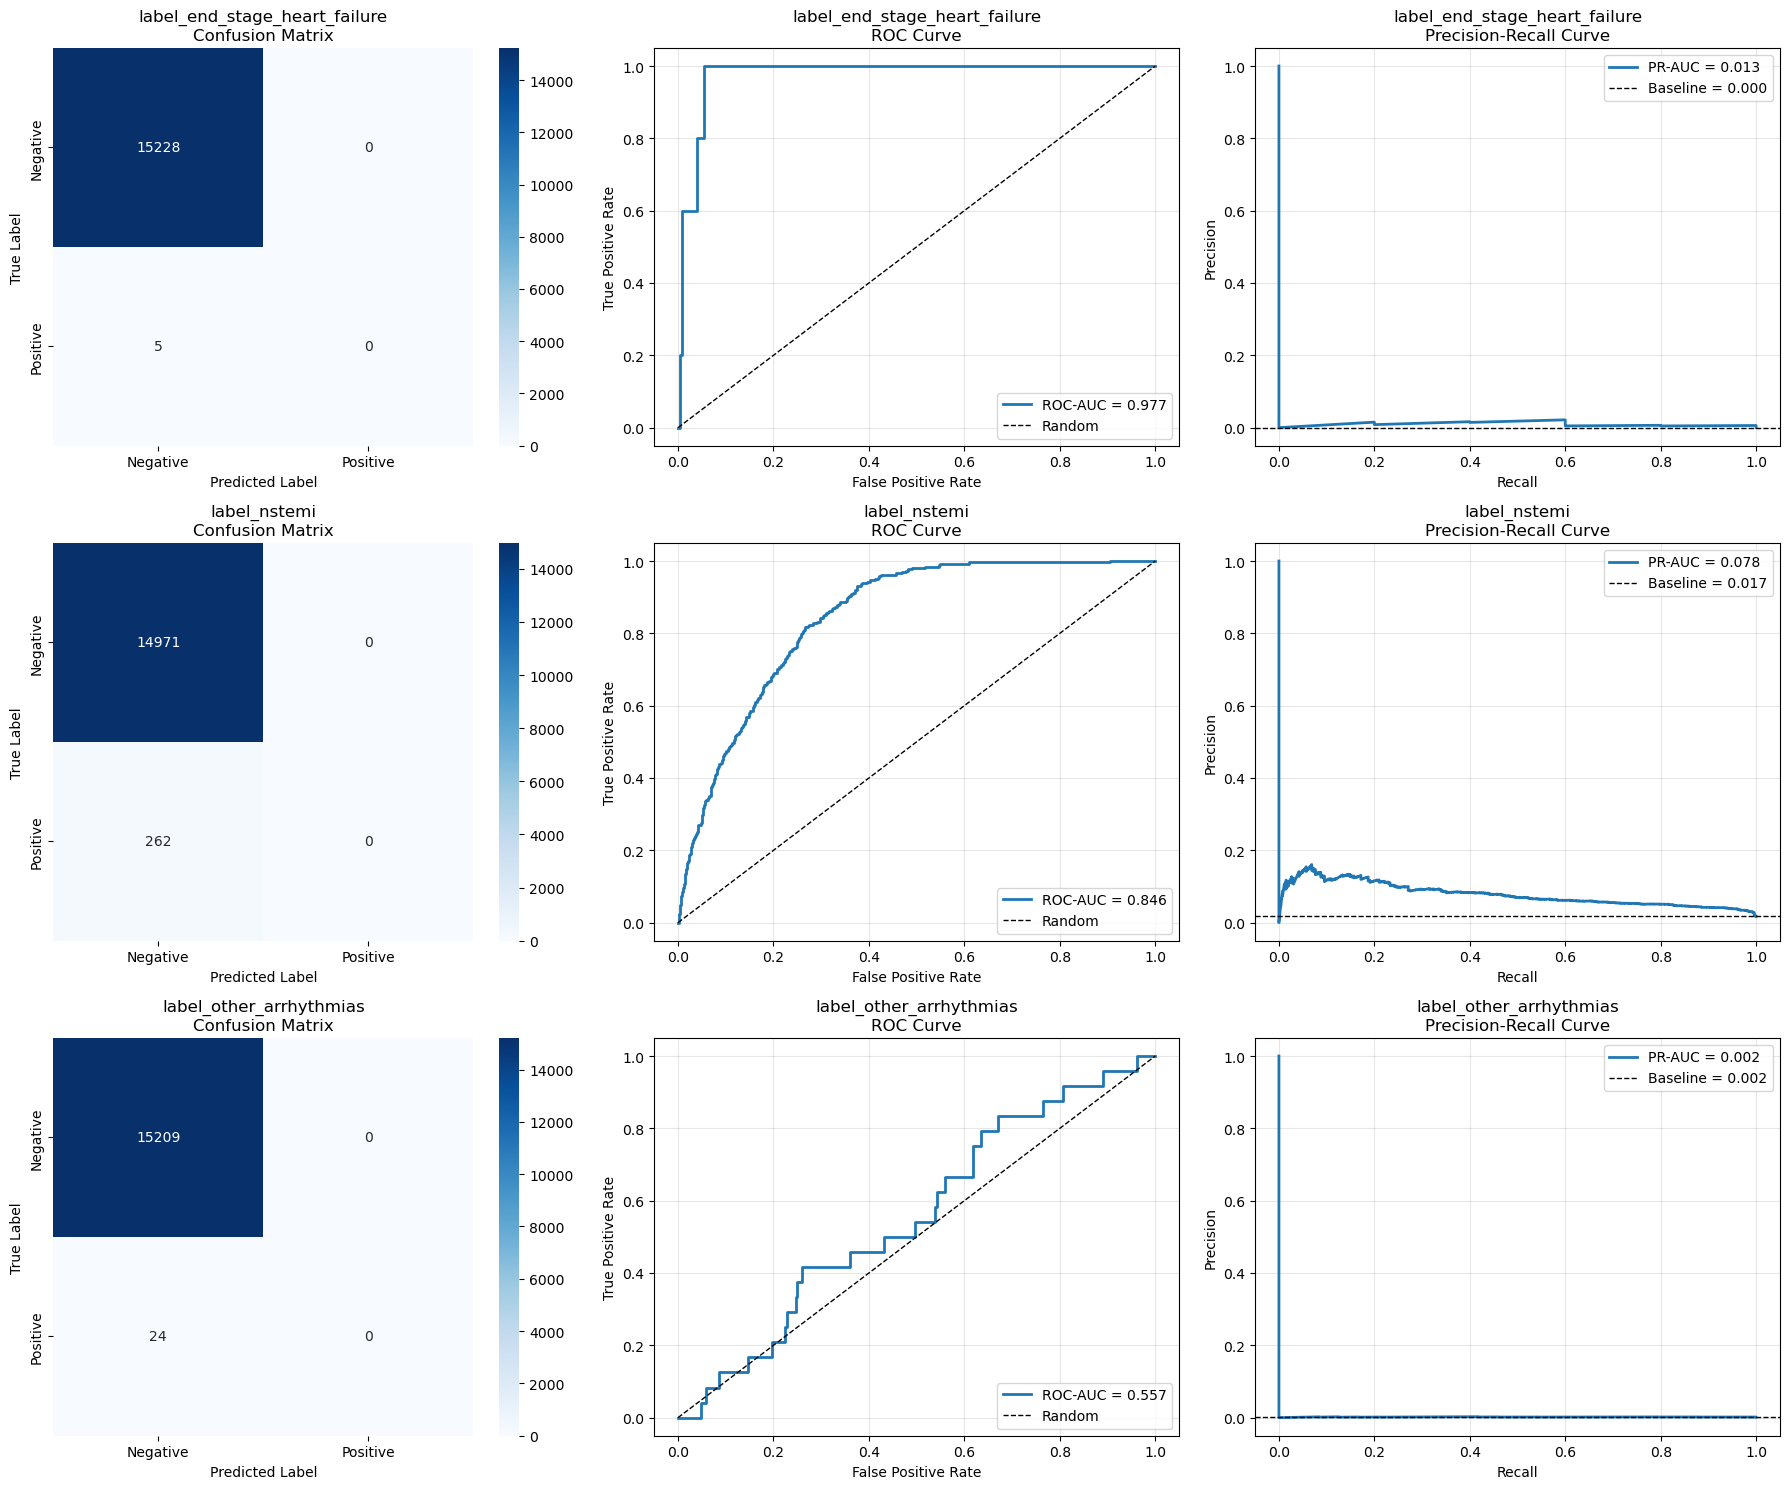


Visualized labels:
  Best:   label_end_stage_heart_failure (ROC-AUC: 0.977)
  Medium: label_nstemi (ROC-AUC: 0.846)
  Worst:  label_other_arrhythmias (ROC-AUC: 0.557)


In [ ]:
# Select a few representative labels to visualize
# Choose: best performer, worst performer, and a medium performer
valid_results_sorted = results_df[results_df['roc_auc'].notna()].sort_values('roc_auc', ascending=False)

best_label = valid_results_sorted.iloc[0]['target']
worst_label = valid_results_sorted.iloc[-1]['target']
medium_label = valid_results_sorted.iloc[len(valid_results_sorted)//2]['target']

selected_labels = [best_label, medium_label, worst_label]
print(f"Visualizing: {selected_labels}")

# Use y.columns instead of machine_report_cols
label_cols_list = y.columns.tolist()

# Create figure with 3 rows, 3 columns
fig, axes = plt.subplots(3, 3, figsize=(18, 15))

for row, label in enumerate(selected_labels):
    # Get index for this label
    label_idx = label_cols_list.index(label)
    
    # Get predictions for this label - use column name directly
    y_true = y_test[label]  # ← Changed back to use column name
    y_pred = multi_xgb.estimators_[label_idx].predict(X_test)
    y_pred_proba = multi_xgb.estimators_[label_idx].predict_proba(X_test)[:, 1]
    
    # Get metrics
    label_metrics = results_df[results_df['target'] == label].iloc[0]
    roc_auc = label_metrics['roc_auc']
    pr_auc = label_metrics['pr_auc']
    
    # Column 1: Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[row, 0],
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    axes[row, 0].set_title(f'{label}\nConfusion Matrix')
    axes[row, 0].set_ylabel('True Label')
    axes[row, 0].set_xlabel('Predicted Label')
    
    # Column 2: ROC Curve
    if y_true.nunique() > 1:  # Only plot if both classes present
        fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
        axes[row, 1].plot(fpr, tpr, linewidth=2, label=f'ROC-AUC = {roc_auc:.3f}')
        axes[row, 1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
        axes[row, 1].set_xlabel('False Positive Rate')
        axes[row, 1].set_ylabel('True Positive Rate')
        axes[row, 1].set_title(f'{label}\nROC Curve')
        axes[row, 1].legend(loc='lower right')
        axes[row, 1].grid(True, alpha=0.3)
    else:
        axes[row, 1].text(0.5, 0.5, 'Single class\nin test set', 
                         ha='center', va='center', fontsize=12)
        axes[row, 1].set_title(f'{label}\nROC Curve (N/A)')
    
    # Column 3: Precision-Recall Curve
    if y_true.nunique() > 1:  # Only plot if both classes present
        precision, recall, _ = precision_recall_curve(y_true, y_pred_proba)
        baseline_precision = y_true.mean()
        axes[row, 2].plot(recall, precision, linewidth=2, label=f'PR-AUC = {pr_auc:.3f}')
        axes[row, 2].axhline(baseline_precision, color='k', linestyle='--', 
                            linewidth=1, label=f'Baseline = {baseline_precision:.3f}')
        axes[row, 2].set_xlabel('Recall')
        axes[row, 2].set_ylabel('Precision')
        axes[row, 2].set_title(f'{label}\nPrecision-Recall Curve')
        axes[row, 2].legend(loc='best')
        axes[row, 2].grid(True, alpha=0.3)
    else:
        axes[row, 2].text(0.5, 0.5, 'Single class\nin test set', 
                         ha='center', va='center', fontsize=12)
        axes[row, 2].set_title(f'{label}\nPR Curve (N/A)')

plt.tight_layout()
plt.show()

print(f"\nVisualized labels:")
print(f"  Best:   {best_label} (ROC-AUC: {valid_results_sorted.iloc[0]['roc_auc']:.3f})")
print(f"  Medium: {medium_label} (ROC-AUC: {valid_results_sorted.iloc[len(valid_results_sorted)//2]['roc_auc']:.3f})")
print(f"  Worst:  {worst_label} (ROC-AUC: {valid_results_sorted.iloc[-1]['roc_auc']:.3f})")


Plotting 65 labels with valid metrics
Plots saved to '../data/model_results/xgboost_baseline_evaluation_plots.png'


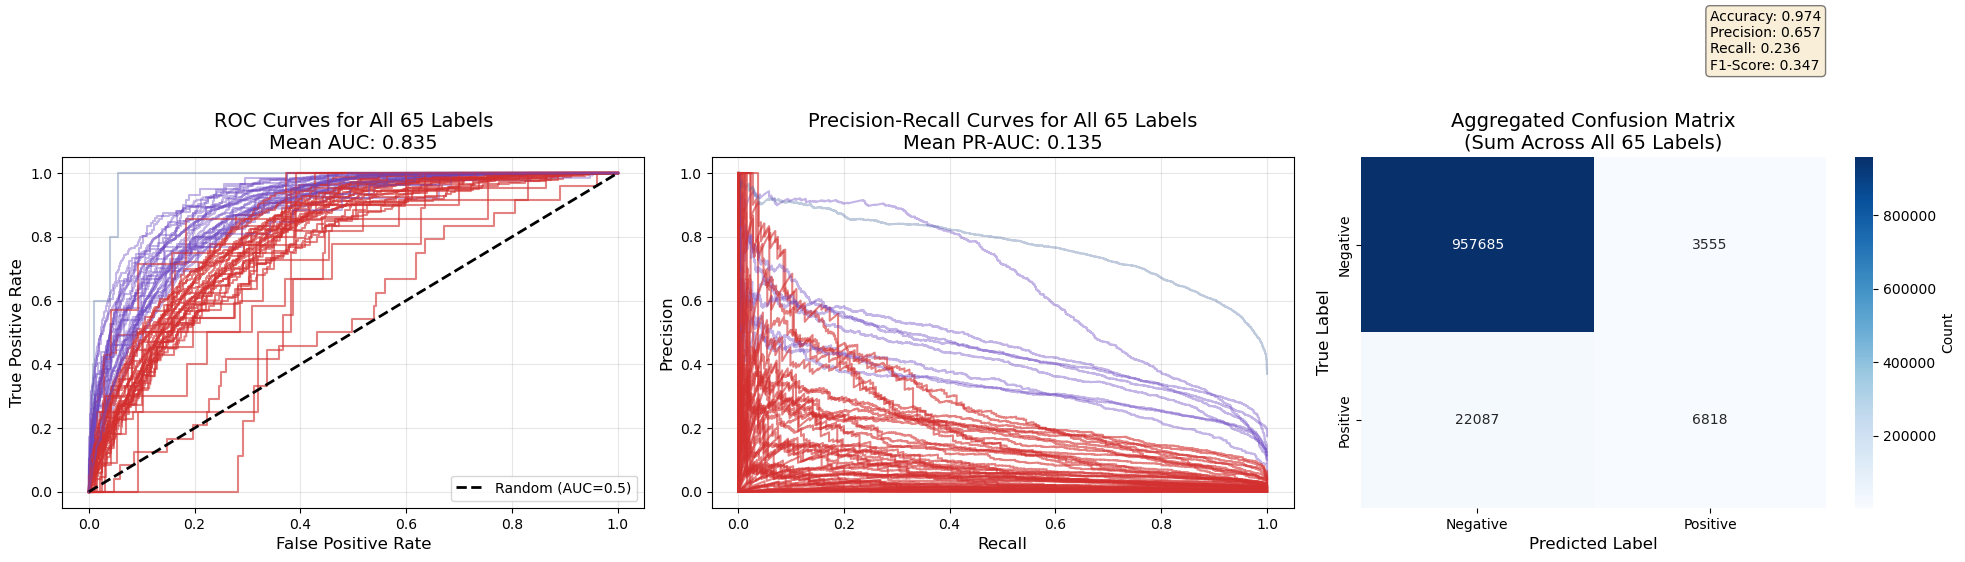


Aggregated Metrics (across all 65 labels):
  Total Predictions: 990145
  True Negatives:  957685 (96.7%)
  False Positives: 3555 (0.4%)
  False Negatives: 22087 (2.2%)
  True Positives:  6818 (0.7%)
  Overall Accuracy: 0.974
  Overall Precision: 0.657
  Overall Recall: 0.236
  Overall F1-Score: 0.347

Results saved to '../data/model_results/xgboost_baseline_diagnosis_results.csv'


,target,n_test_pos,pos_rate,roc_auc,pr_auc
34,label_hypertension,5642,0.370380,0.866703,0.771719
10,label_atrial_fibrillation_flutter,1693,0.111140,0.907771,0.652800
24,label_coronary_artery_disease,1758,0.115407,0.872505,0.454857
26,label_diabetes_mellitus,2659,0.174555,0.799794,0.450253
6,label_anemia,2080,0.136546,0.857188,0.439698
...,...,...,...,...,...
41,label_other_arrhythmias,24,0.001576,0.556628,0.001900
38,label_myocarditis,4,0.000263,0.722306,0.001436
59,label_subsequent_mi,4,0.000263,0.818816,0.000988
63,label_unstable_angina,9,0.000591,0.588990,0.000752


In [ ]:
from models.xgboost_baseline import evaluate_and_visualize_multilabel_model

evaluate_and_visualize_multilabel_model(multi_xgb, X_test, y_test, y_features)